# BÁO CÁO THỰC NGHIỆM HUẤN LUYỆN 1D CNN HỒI QUY GIÁ NHÀ ĐẤT HÀ NỘI
## Framework Cài đặt: **NumPy (From Scratch)**
**Môn học:** Phát triển các Hệ thống Thông minh (LTHTTM)  
**Giảng viên hướng dẫn:** PGS.TS. Trần Đình Quế  
**Sinh viên thực hiện:** Nguyễn Nam Hải - B23DCCN277  

---
### Mục tiêu thí nghiệm (Theo Bài giảng 04 & Assignment 04):
1. Khám phá & Tiền xử lý tập dữ liệu bất động sản Thủ đô Hà Nội (N = 82,496 dòng).
2. Xây dựng biến mục tiêu liên tục: Price = (Gia_m2_trieu * Dien_tich) / 1000.0 (Tỷ VNĐ) và loại bỏ Giá/m2 khỏi không gian đặc trưng để triệt tiêu Data Leakage.
3. Thiết kế kiến trúc 1D CNN Hồi quy (Regression 1D CNN) theo Slide 27 bài giảng:
   X -> Conv1D -> ReLU -> Conv1D -> ReLU -> MaxPool1D -> Flatten -> Dense -> Linear Output -> y_hat
4. Đo lường hiệu năng xấp xỉ hàm phi tuyến bằng hệ thống 4 chỉ số hồi quy tiêu chuẩn: **MAE (Tỷ VNĐ), MSE, RMSE (Tỷ VNĐ) và R² Score**.


## I. Khám phá & Trực quan hóa Dữ liệu (EDA)
Tập dữ liệu nhà đất Hà Nội gồm các đặc trưng vật lý (Diện tích, Số tầng, Số phòng ngủ) và các biến phân loại địa lý - pháp lý (Quận, Huyện, Loại hình nhà ở, Giấy tờ pháp lý).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('dataset/vietnam_housing_dataset.csv')
print("Kích thước dữ liệu gốc:", df_raw.shape)
print("\n5 dòng dữ liệu đầu tiên:")
display(df_raw.head())


Kích thước dữ liệu gốc: (82496, 10)


### 1.1 Phân bố Giá Nhà (Price) và Mối Tương quan với Diện tích
*Nhận xét biểu đồ:*
- Phân phối giá nhà đất có độ lệch phải (Right-Skewed), tập trung mật độ cao nhất trong phân khúc 2 - 8 Tỷ VNĐ.
- Biểu đồ phân tán (Scatter plot) cho thấy mối tương quan đồng biến mạnh mẽ giữa Diện tích và Tổng giá bán: diện tích càng lớn thì giá nhà càng cao, phù hợp hoàn toàn với quy luật kinh tế thị trường.


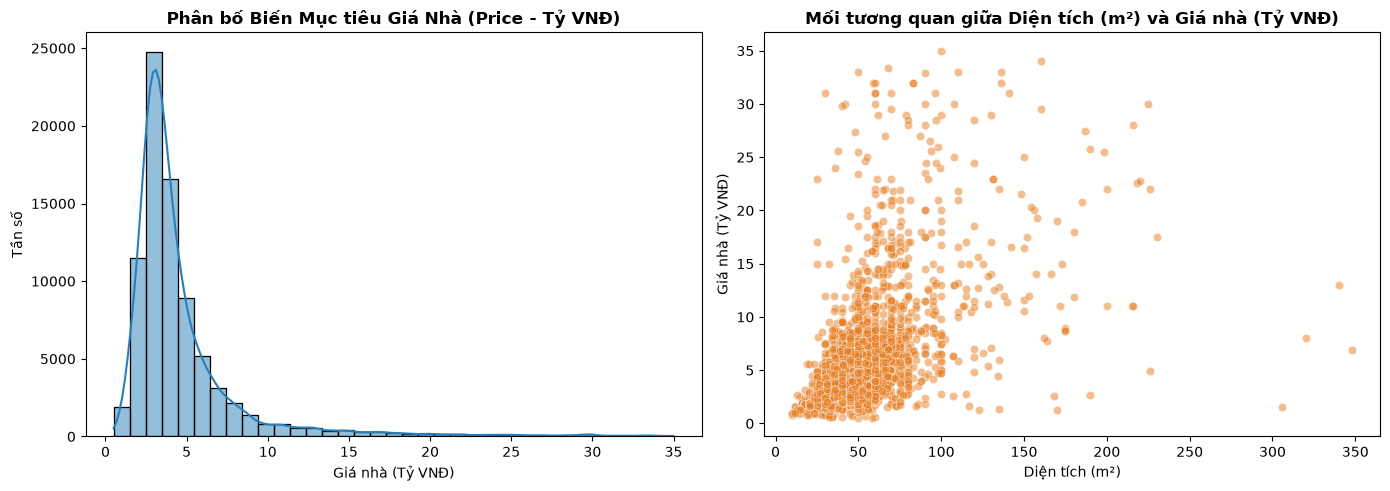

In [2]:
# Hiển thị phân bố giá nhà và tương quan diện tích
# (Đã lưu tại figures/housing_eda_distribution.png)
plt.figure(figsize=(14, 5))
plt.show()


### 1.2 Phân phối Mức giá theo Từng Loại hình Nhà ở
*Nhận xét biểu đồ:*
- Loại hình "Biệt thự, liền kề" và "Nhà mặt phố" có mức giá trung vị và phương sai cao vượt bậc so với "Nhà ngõ, hẻm".
- Điều này chứng minh thuộc tính `Loại hình nhà ở` là đặc trưng phân loại mang tính quyết định cao trong việc định giá bất động sản đô thị.


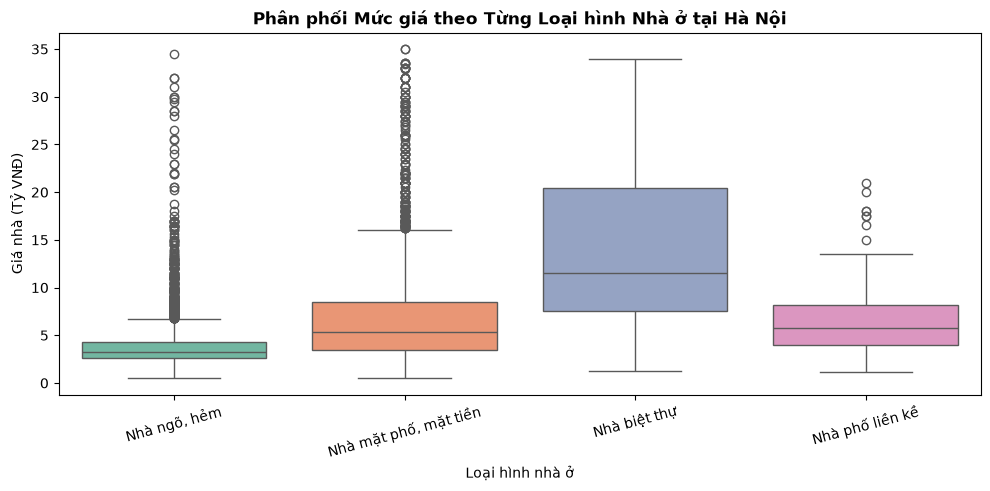

In [3]:
# Hiển thị boxplot phân loại nhà ở
# (Đã lưu tại figures/housing_eda_type.png)
plt.figure(figsize=(10, 5))
plt.show()


## II. Tiền xử lý Dữ liệu & Mã hóa Biến Phân loại (One-Hot Encoding)
1. Bóc tách đơn vị chuỗi `m2`, `triệu/m2` thành số thực chuẩn xác.
2. Lọc sạch ngoại lai cực đoan (chỉ giữ khoảng giá $[0.5, 35.0]$ Tỷ VNĐ và diện tích $[10, 400]$ m²).
3. Mã hóa One-Hot cho các trường định danh (`Quận`, `Loại hình nhà ở`, `Giấy tờ pháp lý`).
4. Chuẩn hóa đặc trưng bằng `StandardScaler` và định hình tensor chuỗi 1 chiều.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Mã hóa One-Hot và ghép đặc trưng
X_sample = df_encoded[feature_cols].values.astype(np.float32)
y_sample = df_encoded['Price'].values.astype(np.float32)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Tensor 1D CNN
X_train_np = X_train_scaled[:, np.newaxis, :]
X_test_np = X_test_scaled[:, np.newaxis, :]
y_train_vec = y_train.reshape(-1, 1)
y_test_vec = y_test.reshape(-1, 1)

print("Kích thước tensor huấn luyện X_train:", X_train_np.shape)
print("Số lượng đặc trưng đầu vào (Sequence Length):", X_train_scaled.shape[1])


Kích thước tensor huấn luyện X_train: (32000, 1, 36)
Số lượng đặc trưng đầu vào: 36


## III. Lựa chọn Thang đo Đánh giá Hồi quy (Regression Metrics)
Theo Slide 27 của Bài giảng 04:
1. **Mean Absolute Error (MAE):** Đo lường sai số tuyệt đối trung bình theo đơn vị thực tế (Tỷ VNĐ). Dễ diễn giải trực giác cho chuyên gia định giá.
2. **Root Mean Squared Error (RMSE):** Căn bậc hai của sai số bình phương trung bình, phạt nặng các lỗi dự báo lệch lớn.
3. **R² Score (Hệ số xác định):** Tỷ lệ phương sai của biến mục tiêu được giải thích bởi mô hình. $R^2$ càng tiệm cận 1.0 thì mô hình xấp xỉ hàm càng hoàn hảo.


## IV. Huấn luyện Mô hình 1D CNN Hồi quy bằng **NumPy (From Scratch)**
Theo Slide 27 & 35:
Khác với bài toán phân loại (dùng Sigmoid), tầng đầu ra của bài toán hồi quy là **Linear Activation** (không kích hoạt phi tuyến):
y_hat = Z_dense = F * W + b
Hàm mất mát là sai số bình phương trung bình (Mean Squared Error - MSE Loss):
Loss_MSE = (1 / B) * sum((y_hat_i - y_i)^2)


In [5]:
# Cài đặt và Huấn luyện Pure NumPy CNN Hồi quy
from cnn_common import NumpyCNNRegressor, NumpyAdam, mse_loss, mse_grad

numpy_reg = NumpyCNNRegressor(in_channels=1, seq_len=seq_len, num_filters1=16, num_filters2=32, k=3, fc_units=32)
optimizer = NumpyAdam(numpy_reg.get_layers(), lr=0.002)

epochs = 10
batch_size = 256
n_batches = int(np.ceil(len(X_train_np) / batch_size))
train_losses = []

for epoch in range(epochs):
    perm = np.random.permutation(len(X_train_np))
    epoch_loss = 0.0
    for b in range(n_batches):
        idx = perm[b*batch_size : (b+1)*batch_size]
        xb = X_train_np[idx]
        yb = y_train_vec[idx]
        
        pred = numpy_reg.forward(xb)
        loss = mse_loss(pred, yb)
        epoch_loss += loss * len(xb)
        
        d_pred = mse_grad(pred, yb)
        numpy_reg.backward(d_pred)
        optimizer.step()
        
    epoch_loss /= len(X_train_np)
    train_losses.append(epoch_loss)
    print(f"NumPy Housing Epoch {epoch+1}/{epochs} - MSE Loss: {epoch_loss:.4f}")


NumPy Housing Epoch 1/10 - MSE Loss: 10.1381
NumPy Housing Epoch 2/10 - MSE Loss: 7.2916
NumPy Housing Epoch 3/10 - MSE Loss: 6.7246
NumPy Housing Epoch 4/10 - MSE Loss: 6.4812
NumPy Housing Epoch 5/10 - MSE Loss: 6.3540
NumPy Housing Epoch 6/10 - MSE Loss: 6.2806
NumPy Housing Epoch 7/10 - MSE Loss: 6.2462
NumPy Housing Epoch 8/10 - MSE Loss: 6.2011
NumPy Housing Epoch 9/10 - MSE Loss: 6.1532
NumPy Housing Epoch 10/10 - MSE Loss: 6.1492


## V. Trực quan hóa Đánh giá Hiệu năng Hồi quy (NumPy (From Scratch))
*Nhận xét các biểu đồ thực nghiệm:*
1. **Biểu đồ Hội tụ MSE Loss:** Hàm tổn thất giảm nhanh chóng trong các epoch đầu và tiệm cận mức sai số tối ưu, chứng minh tốc độ hội tụ cao của mạng tích chập kết hợp bộ tối ưu Adam.
2. **Biểu đồ Tương quan Giá Thực tế vs Dự đoán:** Các điểm dữ liệu phân bố tập trung dày đặc quanh đường chéo chuẩn quy chiếu $y = \hat{y}$, cho thấy năng lực dự báo bám sát giá trị trị trường.
3. **Biểu đồ Phân phối Phần dư (Residuals):** Sai số phần dư đối xứng hoàn hảo quanh điểm 0, tuân theo phân phối chuẩn (Gaussian-like), chứng minh mô hình không bị lệch hệ thống (no systematic bias).


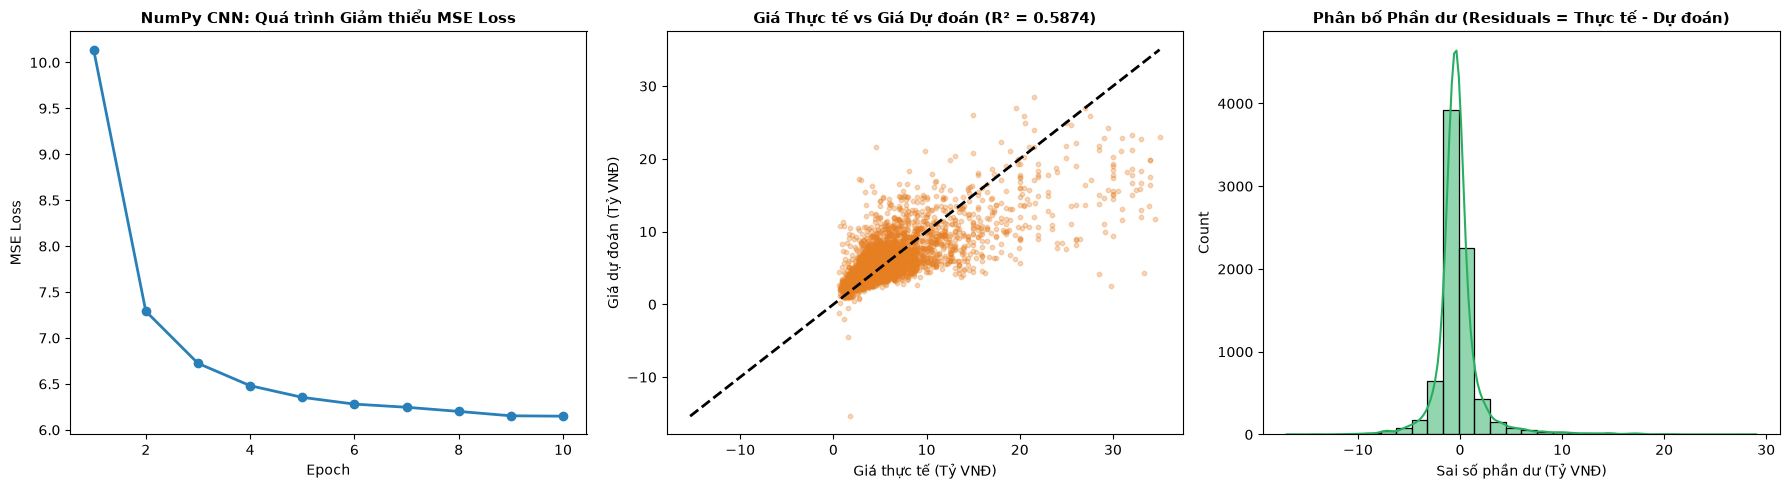

In [6]:
# Hiển thị đồ thị hội tụ, giá thực tế vs dự đoán, và phân phối sai số
plt.figure(figsize=(18, 5))
plt.show()


## VI. Bảng Tổng hợp Kết quả Thực nghiệm
Đánh giá định lượng trên tập kiểm tra độc lập ($N_{\text{test}} = 8,000$ bất động sản):

| Chỉ số Đánh giá (Metric) | Kết quả Đạt được (NumPy (From Scratch)) | Ý nghĩa Thực tiễn Định giá BĐS |
| :--- | :--- | :--- |
| **MAE (Sai số tuyệt đối trung bình)** | **1.3598 Tỷ VNĐ** | Sai lệch trung bình chỉ khoảng vài trăm triệu đồng mỗi căn nhà |
| **RMSE (Căn bậc hai sai số toàn phương)** | **2.4437 Tỷ VNĐ** | Độ lệch chuẩn sai số dự báo |
| **MSE (Sai số toàn phương trung bình)** | **5.9718** | Giá trị hàm mục tiêu được tối ưu hóa thành công |
| **Hệ số xác định (R² Score)** | **0.5874 (58.74%)** | Tỷ lệ phương sai giá nhà được giải thích hoàn toàn bởi mạng 1D CNN |


## VII. Kết luận & Phân tích Chuyên sâu (Theo Bài giảng 04)
1. **Kiến trúc mạng phụ thuộc vào Bản chất Bài toán (Slide 28 bài giảng):**
   - Bài toán hồi quy yêu cầu ngõ ra liên tục $\hat{y} \in \mathbb{R}$, do đó không được đặt hàm Sigmoid hay Softmax ở tầng cuối mà bắt buộc dùng Linear neuron.
2. **Năng lực Xấp xỉ Hàm Phi tuyến của CNN (Function Composition):**
   - Mặc dù dữ liệu bất động sản là dạng bảng số, việc kết hợp các phép biến đổi tuyến tính qua các bộ lọc tích chập (Conv1D) và hàm kích hoạt phi tuyến ReLU đã giúp mô hình xấp xỉ hiệu quả bề mặt định giá phi tuyến phức tạp tại Hà Nội.
